# 05 — Leakage-safe player-snapshot feature engineering

Build a local modelling panel for the fixed Day 4 target:

> Operational churn is no positive betting activity (`Bets > 0`) during the 60 days
> immediately following a prediction snapshot. This represents extended inactivity
> rather than guaranteed permanent customer departure; reactivation remains possible.

Every transaction predictor uses only [S−29, S], where S is an end-of-day monthly
snapshot. The target uses (S, S+60]. A player needs at least one historical positive-bet
day and complete history/outcome coverage. The expected panel has 18,472 observations,
4,025 players, 6,607 churn labels, and 11,865 non-churn labels.

Reusable code: `src/features.py`. Documentation: `docs/feature_dictionary.md`.
Export: `data/processed/model_panel_60d.csv` (local and Git-ignored).
No model training, scaling, encoding, resampling, or hyperparameter tuning occurs.
Result-based interpretations reflect these inputs; update them if the source changes.

## 1. Load and validate the cleaned inputs
Parse the four dates explicitly and validate grains, amounts, missingness, player
coverage, and date endpoints. Keep all financial rows, including zero-Bets transactions
and negative-Winnings accounting corrections. A separate positive-bet activity rule is
used for eligibility, frequency, recency, gaps, and the target.

In [1]:
from pathlib import Path
import sys
import hashlib
import json
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / 'src/features.py').is_file() and (p / 'data/processed/daily_activity_clean.csv').is_file()), None)
if project_root is None:
    raise FileNotFoundError('Run from the project root or notebooks directory.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from src.features import (PREDICTOR_COLUMNS, CATEGORICAL_COLUMNS, METADATA_COLUMNS,
    TARGET_COLUMN, validate_inputs, build_model_panel, validate_panel,
    build_snapshot_features, proposed_temporal_split, write_feature_dictionary)

input_paths = [project_root / 'data/processed' / name for name in
               ['demographics_clean.csv','daily_activity_clean.csv']]
input_hashes = {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in input_paths}
demographics = pd.read_csv(input_paths[0], dtype={c:'int64' for c in
                           ['UserID','Country','Language','Gender']})
daily = pd.read_csv(input_paths[1], dtype={'UserID':'int64','Bets':'int64'},
                    float_precision='round_trip')
for col in ['RegDate','Fstpdate','Fstcadate']:
    demographics[col] = pd.to_datetime(demographics[col], format='%Y-%m-%d', errors='raise')
daily['Date'] = pd.to_datetime(daily.Date, format='%Y-%m-%d', errors='raise')
validate_inputs(demographics,daily)
assert demographics.shape == (4222,7) and daily.shape == (98991,5)
assert set(demographics.UserID) == set(daily.UserID)
assert daily.Date.min() == pd.Timestamp('2005-02-01')
assert daily.Date.max() == pd.Timestamp('2007-02-28')
pd.set_option('display.max_rows',80)
pd.set_option('display.max_columns',20)
pd.set_option('display.precision',3)
FIGURE_DIR = project_root / 'reports/figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi':110,'savefig.dpi':180,'font.size':10,
    'axes.titlesize':14,'axes.labelsize':11,'axes.spines.top':False,
    'axes.spines.right':False,'axes.facecolor':'#f8fafc','figure.facecolor':'white'})
COLORS = {0:'#2563a6',1:'#b66a31'}
saved_figures, section_notes = [], {}
def save_show(fig,name):
    fig.savefig(FIGURE_DIR/name,bbox_inches='tight')
    saved_figures.append(name)
    plt.show()
    plt.close(fig)

date_ranges = pd.DataFrame([{'dataset':name,'field':col,
    'first':frame[col].min(),'last':frame[col].max()} for name,frame,cols in
    [('Demographics',demographics,['RegDate','Fstpdate','Fstcadate']),
     ('Daily activity',daily,['Date'])] for col in cols])
display(date_ranges)
first_observed = daily.loc[daily.Bets.gt(0)].groupby('UserID').Date.min()
source_lifecycle = demographics.set_index('UserID').join(first_observed.rename('first_observed_bet'))
casino_inconsistencies = source_lifecycle.Fstcadate.gt(source_lifecycle.first_observed_bet)
display(pd.Series({'players':len(demographics),'all_player_days':len(daily),
    'positive_bet_player_days':int(daily.Bets.gt(0).sum()),
    'negative_winnings_days':int(daily.Winnings.lt(0).sum()),
    'demographic_first_casino_later_than_first_observed_bet':int(casino_inconsistencies.sum())},name='count').to_frame())
section_notes['inputs'] = f"""**Interpretation.** Input shapes, player coverage, and date endpoints
match the earlier notebooks. {casino_inconsistencies.sum():,} players have a demographic
first-casino date later than their first observed positive-bet date. A source event
that is still in the future at S is unavailable then: mask its tenure feature instead
of exposing the future date or replacing it from later activity. Past source dates are
retained. Financial records are unchanged."""

,dataset,field,first,last
0,Demographics,RegDate,2005-02-01,2005-02-28
1,Demographics,Fstpdate,2005-02-01,2007-01-25
2,Demographics,Fstcadate,2005-02-01,2007-01-30
3,Daily activity,Date,2005-02-01,2007-02-28


,count
players,4222
all_player_days,98991
positive_bet_player_days,98949
negative_winnings_days,69
demographic_first_casino_later_than_first_observed_bet,105


**Interpretation.** Input shapes, player coverage, and date endpoints
match the earlier notebooks. 105 players have a demographic
first-casino date later than their first observed positive-bet date. A source event
that is still in the future at S is unavailable then: mask its tenure feature instead
of exposing the future date or replacing it from later activity. Past source dates are
retained. Financial records are unchanged.

## 2. Feature conventions and panel construction

- All 7-, 14-, and 30-day windows end at S and include exactly that many dates.
- Early trend period is [S−29, S−15]; recent period is [S−14, S], each 15 dates.
- Active-day counts require positive Bets. Monetary and bet totals sum all cleaned rows.
- Safe division returns missing for zero denominators, including 0/0. Percentage changes
  are percentages (×100), whereas shares are fractions between 0 and 1. Zero early
  activity is not fabricated as a finite growth rate.
- Completed gaps count full inactive dates (date difference − 1) between positive-bet
  dates **inside** the 30-day window. Fewer than two dates means missing gaps. Leading
  and trailing inactivity are excluded; recency covers the latter separately.
- Daily stake max/median/std use **all 30 calendar dates**, zero-filling dates without
  records while retaining recorded financial days. Std uses population `ddof=0`.
  This convention makes the statistic describe daily behaviour, not only transaction days.
- Lifecycle tenures use demographic event dates only when on/before S. Raw category
  codes remain integers with a categorical modelling role; no encoding occurs.
- `UserID` and `snapshot_date` are metadata. `churn_60d` is the target. The explicit
  predictor list excludes all three. Features and targets are built by separate functions.

The exported panel contains all eligible observations, including snapshots later proposed
for embargo. The split assignment stays separate so excluded rows cannot be silently
treated as training data.

In [2]:
panel = build_model_panel(demographics,daily)
coverage_audit = validate_panel(panel,demographics,daily)
expected = {'observations':18472,'unique_players':4025,'churn':6607,'non_churn':11865}
actual = {'observations':len(panel),'unique_players':panel.UserID.nunique(),
          'churn':int(panel.churn_60d.sum()),'non_churn':int(panel.churn_60d.eq(0).sum())}
display(pd.DataFrame({'expected':expected,'actual':actual}))
assert actual == expected, 'Panel differs from Day 4; investigate before exporting.'
assert panel.shape == (18472,48) and len(PREDICTOR_COLUMNS) == 45
assert panel.snapshot_date.min() == pd.Timestamp('2005-03-31')
assert panel.snapshot_date.max() == pd.Timestamp('2006-11-30')
display(coverage_audit)
display(panel.head())
display(pd.DataFrame({'predictor':PREDICTOR_COLUMNS,
    'dtype':[str(panel[c].dtype) for c in PREDICTOR_COLUMNS]}))
section_notes['panel'] = f"""**Interpretation.** The panel matches Day 4 exactly:
{len(panel):,} observations × {panel.shape[1]} columns, with {len(PREDICTOR_COLUMNS)} predictors,
two metadata columns, and one target. It covers {panel.snapshot_date.nunique()} monthly
snapshots and {panel.UserID.nunique():,} players; {panel.churn_60d.sum():,} churn and
{panel.churn_60d.eq(0).sum():,} non-churn observations give {panel.churn_60d.mean()*100:.2f}% churn.
The independent date-array audit checks eligibility and exact label boundaries for
every observation, including exclusion of snapshot-day activity from the target."""

,expected,actual
observations,18472,18472
unique_players,4025,4025
churn,6607,6607
non_churn,11865,11865


,snapshot_date,feature_start,feature_end,outcome_start,outcome_end,observations_audited
0,2005-03-31,2005-03-02,2005-03-31,2005-04-01,2005-05-30,1805
1,2005-04-30,2005-04-01,2005-04-30,2005-05-01,2005-06-29,1314
2,2005-05-31,2005-05-02,2005-05-31,2005-06-01,2005-07-30,1022
3,2005-06-30,2005-06-01,2005-06-30,2005-07-01,2005-08-29,876
4,2005-07-31,2005-07-02,2005-07-31,2005-08-01,2005-09-29,819
5,2005-08-31,2005-08-02,2005-08-31,2005-09-01,2005-10-30,871
6,2005-09-30,2005-09-01,2005-09-30,2005-10-01,2005-11-29,1043
7,2005-10-31,2005-10-02,2005-10-31,2005-11-01,2005-12-30,902
8,2005-11-30,2005-11-01,2005-11-30,2005-12-01,2006-01-29,873
9,2005-12-31,2005-12-02,2005-12-31,2006-01-01,2006-03-01,855


,UserID,snapshot_date,active_days_30d,bets_30d,active_days_14d,bets_14d,active_days_7d,bets_7d,avg_bets_per_active_day_30d,avg_bets_per_active_day_7d,...,active_days_early15,active_days_change_15d,active_days_change_pct_15d,days_since_registration,days_since_first_pay,days_since_first_casino_activity,Country,Language,Gender,churn_60d
0,1324369,2005-03-31,1,60,1,60,1,60,60.000,60.0,...,0,1,NaN,58,58,30.0,792,7,1,0
1,1324400,2005-03-31,3,1337,0,0,0,0,445.667,NaN,...,3,-3,-100.000,58,58,41.0,276,1,1,1
2,1324408,2005-03-31,7,1028,3,252,1,27,146.857,27.0,...,4,-1,-25.000,58,51,50.0,250,6,1,0
3,1324503,2005-03-31,14,472,4,41,2,22,33.714,11.0,...,9,-4,-44.444,58,57,57.0,300,8,1,0
4,1324591,2005-03-31,2,13,1,9,1,9,6.500,9.0,...,1,0,0.000,58,57,57.0,792,7,1,0


,predictor,dtype
0,active_days_30d,int64
1,bets_30d,int64
2,active_days_14d,int64
3,bets_14d,int64
4,active_days_7d,int64
5,bets_7d,int64
6,avg_bets_per_active_day_30d,float64
7,avg_bets_per_active_day_7d,float64
8,days_since_last_active_bet,int64
9,max_gap_between_active_days_30d,float64


**Interpretation.** The panel matches Day 4 exactly:
18,472 observations × 48 columns, with 45 predictors,
two metadata columns, and one target. It covers 21 monthly
snapshots and 4,025 players; 6,607 churn and
11,865 non-churn observations give 35.77% churn.
The independent date-array audit checks eligibility and exact label boundaries for
every observation, including exclusion of snapshot-day activity from the target.

## 3. Leakage safeguards, missingness, and invariants
Run hand-calculated boundary tests and future-invariance tests from `tests/test_features.py`.
Additionally rebuild each actual snapshot after removing **every future transaction**;
the predictors must be identical. The production audit verifies nonnegative values where
required, finite ratios, window coverage, nested count constraints, trend partitions,
and exact permitted missingness. Signed changes, Winnings, and net loss can be negative.
Report every predictor, including zero-missing columns; no imputation is performed.

In [3]:
test_run = subprocess.run([sys.executable,'-m','unittest','discover','-s','tests','-v'],
    cwd=project_root,capture_output=True,text=True,check=True)
print(test_run.stdout + test_run.stderr)
for snapshot, rows in panel.groupby('snapshot_date'):
    past_only = daily.loc[daily.Date.le(snapshot)].copy()
    rebuilt = build_snapshot_features(demographics,past_only,snapshot)
    expected_features = rows[METADATA_COLUMNS+PREDICTOR_COLUMNS].reset_index(drop=True)
    pd.testing.assert_frame_equal(expected_features,rebuilt,check_dtype=False)
print('All 21 actual snapshots are invariant to removing future activity.')

missing_report = pd.DataFrame({'missing_count':panel[PREDICTOR_COLUMNS].isna().sum(),
    'missing_pct':panel[PREDICTOR_COLUMNS].isna().mean()*100,
    'infinite_count':np.isinf(panel[PREDICTOR_COLUMNS].to_numpy(dtype=float)).sum(axis=0)})
display(missing_report)
legitimate_missingness = {
    'avg_bets_per_active_day_7d':'No positive-bet activity in the last 7 days.',
    'max_gap_between_active_days_30d':'Only one active day; no completed between-day gap.',
    'mean_gap_between_active_days_30d':'Only one active day; no completed between-day gap.',
    'stake_7d_share':'Zero total 30-day stake despite positive Bets.',
    'bets_change_pct_15d':'Zero early-period Bets; percentage growth is undefined.',
    'stake_change_pct_15d':'Zero early-period Stake; percentage growth is undefined.',
    'active_days_change_pct_15d':'Zero early-period active days; percentage growth is undefined.',
    'days_since_registration':'Source registration event is after the snapshot.',
    'days_since_first_pay':'Source first-pay event is after the snapshot.',
    'days_since_first_casino_activity':'Source first-casino event is after the snapshot.'}
missing_nonzero = missing_report.loc[missing_report.missing_count.gt(0)].copy()
missing_nonzero['explanation'] = [legitimate_missingness[c] for c in missing_nonzero.index]
display(missing_nonzero)
missing_entries = int(panel[PREDICTOR_COLUMNS].isna().sum().sum())
missing_rows = int(panel[PREDICTOR_COLUMNS].isna().any(axis=1).sum())
section_notes['missing'] = f"""**Interpretation.** There are **zero infinite values** and
{missing_entries:,} missing predictor entries across {missing_rows:,} observations.
Missingness occurs in {len(missing_nonzero)} predictors and exactly matches the documented
zero-denominator, insufficient-gap, or future-event conditions.
{panel.days_since_first_casino_activity.isna().sum():,} player-snapshots have a future-dated
first-casino event and therefore a missing as-of tenure; these represent
{panel.loc[panel.days_since_first_casino_activity.isna(),'UserID'].nunique():,} players.
No rows are dropped or missing ratios imputed. Any future imputer and encoder must be
fitted on training data only. Calendar-day median stake may often be zero for intermittent
players; that is a measured convention, not missingness. All tests passed, including
full predictor invariance to removal of future transactions."""

test_features_unchanged_when_future_is_removed_or_changed (test_features.FeatureContractTests.test_features_unchanged_when_future_is_removed_or_changed) ... ok
test_hand_calculated_history_and_financial_corrections (test_features.FeatureContractTests.test_hand_calculated_history_and_financial_corrections) ... ok
test_legitimate_missing_values_and_negative_net_loss (test_features.FeatureContractTests.test_legitimate_missing_values_and_negative_net_loss) ... ok
test_reject_incomplete_history_and_duplicate_days (test_features.FeatureContractTests.test_reject_incomplete_history_and_duplicate_days) ... ok
test_target_exact_boundaries_zero_bets_and_censoring (test_features.FeatureContractTests.test_target_exact_boundaries_zero_bets_and_censoring) ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.422s

OK



All 21 actual snapshots are invariant to removing future activity.


,missing_count,missing_pct,infinite_count
active_days_30d,0,0.000,0
bets_30d,0,0.000,0
active_days_14d,0,0.000,0
bets_14d,0,0.000,0
active_days_7d,0,0.000,0
bets_7d,0,0.000,0
avg_bets_per_active_day_30d,0,0.000,0
avg_bets_per_active_day_7d,10188,55.154,0
days_since_last_active_bet,0,0.000,0
max_gap_between_active_days_30d,5766,31.215,0


,missing_count,missing_pct,infinite_count,explanation
avg_bets_per_active_day_7d,10188,55.154,0,No positive-bet activity in the last 7 days.
max_gap_between_active_days_30d,5766,31.215,0,Only one active day; no completed between-day ...
mean_gap_between_active_days_30d,5766,31.215,0,Only one active day; no completed between-day ...
stake_7d_share,464,2.512,0,Zero total 30-day stake despite positive Bets.
bets_change_pct_15d,5086,27.534,0,Zero early-period Bets; percentage growth is u...
stake_change_pct_15d,5484,29.688,0,Zero early-period Stake; percentage growth is ...
active_days_change_pct_15d,5086,27.534,0,Zero early-period active days; percentage grow...
days_since_first_casino_activity,35,0.189,0,Source first-casino event is after the snapshot.


**Interpretation.** There are **zero infinite values** and
37,875 missing predictor entries across 13,690 observations.
Missingness occurs in 8 predictors and exactly matches the documented
zero-denominator, insufficient-gap, or future-event conditions.
35 player-snapshots have a future-dated
first-casino event and therefore a missing as-of tenure; these represent
30 players.
No rows are dropped or missing ratios imputed. Any future imputer and encoder must be
fitted on training data only. Calendar-day median stake may often be zero for intermittent
players; that is a measured convention, not missingness. All tests passed, including
full predictor invariance to removal of future transactions.

## 4. Descriptive comparison of churn and non-churn
Compare required features with count, median, mean, and quartiles. Display all four
requested charts; percentage changes use a signed log axis to retain the full tail.
Missing values are excluded only from their own chart/statistic and are counted above.
No outliers are removed. These are pooled player-snapshot associations with repeated
players and varying calendar cohorts, not significance tests, causal effects, or model
performance. No feature selection is made from these comparisons.

,,nonmissing,missing,median,mean,Q1,Q3
feature,group,,,,,,
active_days_30d,Non-churn,11865,0,3.000,5.452,2.0,7.000
bets_30d,Non-churn,11865,0,95.000,830.595,19.0,520.000
stake_30d,Non-churn,11865,0,686.500,6821.257,110.0,4083.250
days_since_last_active_bet,Non-churn,11865,0,5.000,8.106,1.0,14.000
active_days_change_15d,Non-churn,11865,0,0.000,0.050,-2.0,2.000
bets_change_pct_15d,Non-churn,8614,3251,-67.553,402.621,-100.0,33.757
active_days_30d,Churn,6607,0,2.000,2.652,1.0,3.000
bets_30d,Churn,6607,0,33.000,289.295,7.0,158.000
stake_30d,Churn,6607,0,154.000,2174.152,29.0,783.250


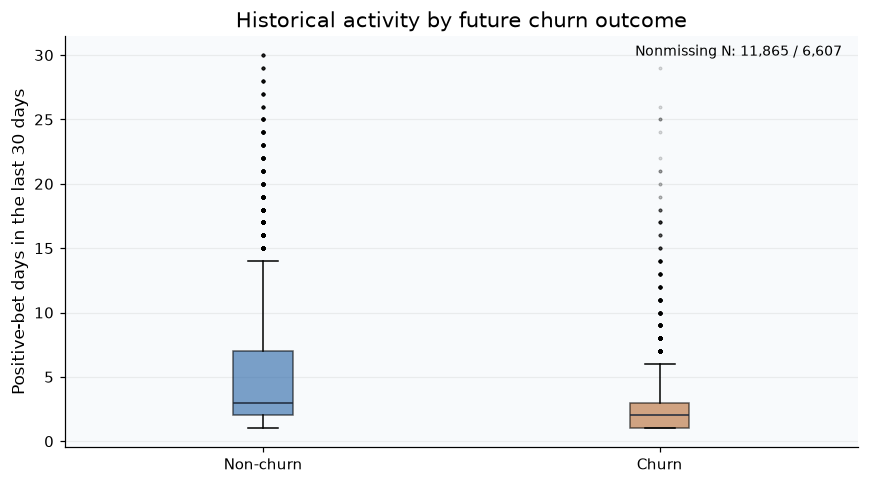

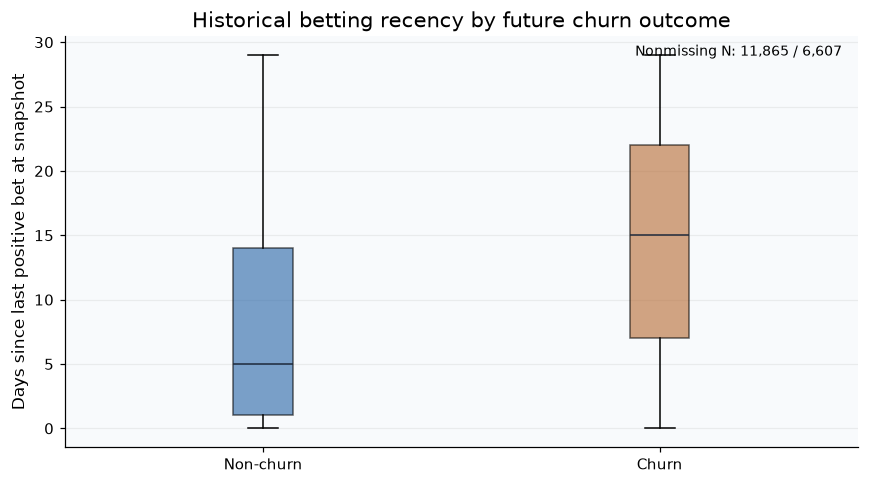

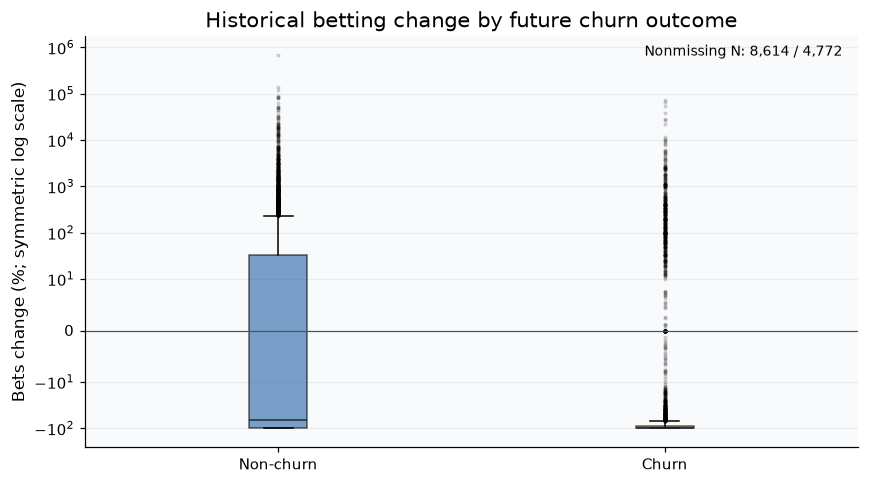

,observations,unique_players,churn_count,churn_rate,churn_pct
snapshot_date,,,,,
2005-03-31,1805,1805,725,0.402,40.166
2005-04-30,1314,1314,516,0.393,39.269
2005-05-31,1022,1022,376,0.368,36.791
2005-06-30,876,876,299,0.341,34.132
2005-07-31,819,819,269,0.328,32.845
2005-08-31,871,871,262,0.301,30.080
2005-09-30,1043,1043,364,0.349,34.899
2005-10-31,902,902,328,0.364,36.364
2005-11-30,873,873,318,0.364,36.426


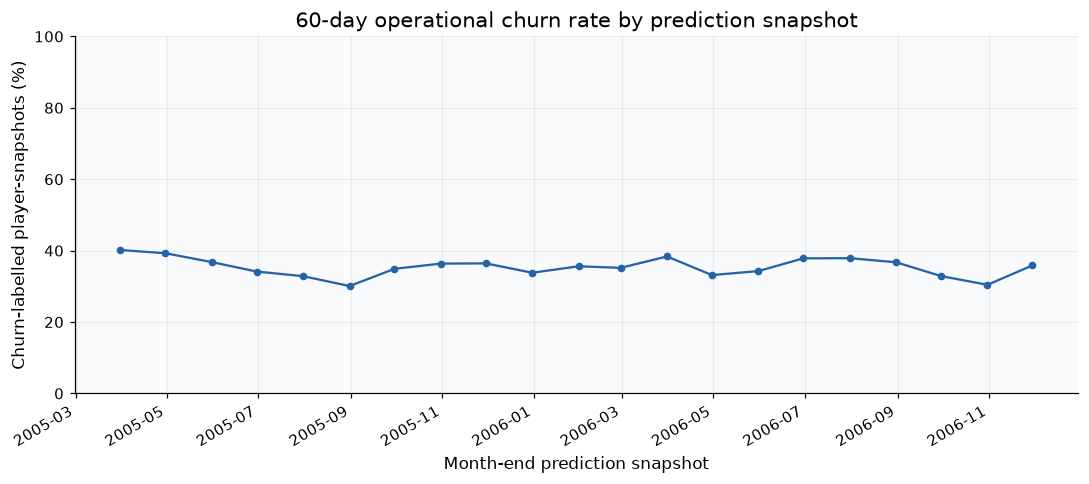

In [4]:
comparison_features = ['active_days_30d','bets_30d','stake_30d',
    'days_since_last_active_bet','active_days_change_15d','bets_change_pct_15d']
comparison_rows = []
for target, group in panel.groupby('churn_60d'):
    for feature in comparison_features:
        values=group[feature]
        comparison_rows.append({'group':'Churn' if target else 'Non-churn','feature':feature,
            'nonmissing':values.count(),'missing':values.isna().sum(),'median':values.median(),
            'mean':values.mean(),'Q1':values.quantile(.25),'Q3':values.quantile(.75)})
comparison = pd.DataFrame(comparison_rows).set_index(['feature','group'])
display(comparison)

for feature,title,ylabel,filename in [
    ('active_days_30d','Historical activity by future churn outcome','Positive-bet days in the last 30 days','churn_vs_nonchurn_active_days_30d.png'),
    ('days_since_last_active_bet','Historical betting recency by future churn outcome','Days since last positive bet at snapshot','churn_vs_nonchurn_betting_recency.png'),
    ('bets_change_pct_15d','Historical betting change by future churn outcome','Bets change (%; symmetric log scale)','churn_vs_nonchurn_bets_change_pct_15d.png')]:
    fig,ax=plt.subplots(figsize=(8,4.5))
    data=[panel.loc[panel.churn_60d.eq(t),feature].dropna().to_numpy() for t in [0,1]]
    box=ax.boxplot(data,tick_labels=['Non-churn','Churn'],patch_artist=True,
        showfliers=True,medianprops={'color':'#1e293b'},
        flierprops={'marker':'.','markersize':3,'alpha':.2})
    for patch,color in zip(box['boxes'],[COLORS[0],COLORS[1]]):
        patch.set_facecolor(color); patch.set_alpha(.6)
    if feature=='bets_change_pct_15d':
        ax.set_yscale('symlog',linthresh=10)
        ax.axhline(0,color='#475569',linewidth=.8)
    ax.set(title=title,ylabel=ylabel)
    ax.grid(axis='y',alpha=.2)
    ax.text(.98,.98,f'Nonmissing N: {len(data[0]):,} / {len(data[1]):,}',
            transform=ax.transAxes,ha='right',va='top',fontsize=9)
    fig.tight_layout(); save_show(fig,filename)

monthly = panel.groupby('snapshot_date').agg(observations=('UserID','size'),
    unique_players=('UserID','nunique'),churn_count=('churn_60d','sum'),churn_rate=('churn_60d','mean'))
monthly['churn_pct']=monthly.churn_rate*100
display(monthly)
fig,ax=plt.subplots(figsize=(10,4.5))
ax.plot(monthly.index,monthly.churn_pct,color='#2563a6',marker='o',markersize=4)
ax.set(title='60-day operational churn rate by prediction snapshot',
       xlabel='Month-end prediction snapshot',ylabel='Churn-labelled player-snapshots (%)',ylim=(0,100))
ax.grid(alpha=.2); fig.autofmt_xdate()
fig.tight_layout(); save_show(fig,'feature_panel_churn_rate_by_snapshot.png')

medians=panel.groupby('churn_60d')[comparison_features].median()
section_notes['comparison'] = f"""**Interpretation.** Non-churn versus churn medians are:

- Active days (30d): **{medians.loc[0,'active_days_30d']:g} vs {medians.loc[1,'active_days_30d']:g}**.
- Bets (30d): **{medians.loc[0,'bets_30d']:,.0f} vs {medians.loc[1,'bets_30d']:,.0f}**.
- Stake (30d): **€{medians.loc[0,'stake_30d']:,.2f} vs €{medians.loc[1,'stake_30d']:,.2f}**.
- Days since last active bet: **{medians.loc[0,'days_since_last_active_bet']:g} vs {medians.loc[1,'days_since_last_active_bet']:g}**.
- Active-day change between 15-day halves: **{medians.loc[0,'active_days_change_15d']:g} vs {medians.loc[1,'active_days_change_15d']:g}**.
- Bets percentage change, among defined values: **{medians.loc[0,'bets_change_pct_15d']:.1f}% vs {medians.loc[1,'bets_change_pct_15d']:.1f}%**.

These are the main descriptive separations to examine in later training-only analysis;
they do not establish predictive importance. Monthly churn rates range from
{monthly.churn_pct.min():.1f}% to {monthly.churn_pct.max():.1f}%. Monetary means are
sensitive to the retained upper tail, and undefined growth denominators must not be
mistaken for no behavioural change. Inspecting these distributions does not tune a model."""

**Interpretation.** Non-churn versus churn medians are:

- Active days (30d): **3 vs 2**.
- Bets (30d): **95 vs 33**.
- Stake (30d): **€686.50 vs €154.00**.
- Days since last active bet: **5 vs 15**.
- Active-day change between 15-day halves: **0 vs -1**.
- Bets percentage change, among defined values: **-67.6% vs -100.0%**.

These are the main descriptive separations to examine in later training-only analysis;
they do not establish predictive importance. Monthly churn rates range from
30.1% to 40.2%. Monetary means are
sensitive to the retained upper tail, and undefined growth denominators must not be
mistaken for no behavioural change. Inspecting these distributions does not tune a model.

## 5. Proposed temporal split with embargo
Inspect the actual snapshot list and reserve an early training period, middle-late
validation period, and latest test period. Two intervening monthly snapshots are omitted
at each transition. Require at least 60 days between adjacent split boundaries, and
add the stronger check that each later observation window starts **after** the earlier
split's final target window ends.

An adjacent-month split would leave some training outcomes extending beyond later
prediction dates. An embargo keeps those future labels out of earlier training decisions.
These periods also avoid direct overlap of earlier outcomes with later feature windows.
Rows within each split still overlap and repeat players; evaluation targets future
behaviour of known/recently active players. It does not claim unseen-player generalisation.
The test period stays reserved for later final evaluation; this notebook trains nothing.

In [5]:
proposed_split, split_summary = proposed_temporal_split(panel)
display(split_summary)
split_snapshot_dates = pd.DataFrame({'snapshot_date':panel.snapshot_date,
    'proposed_split':proposed_split}).drop_duplicates().sort_values('snapshot_date')
display(split_snapshot_dates)
boundary_rows=[]
for earlier,later in [('train','validation'),('validation','test')]:
    last=split_summary.loc[earlier,'last_snapshot']
    first=split_summary.loc[later,'first_snapshot']
    boundary_rows.append({'transition':f'{earlier} → {later}',
        'last_earlier_snapshot':last,'first_later_snapshot':first,
        'snapshot_gap_days':(first-last).days,
        'earlier_outcome_end':last+pd.Timedelta(days=60),
        'later_feature_start':first-pd.Timedelta(days=29)})
display(pd.DataFrame(boundary_rows))
assert len(proposed_split)==len(panel)
assert split_summary.observations.sum()==len(panel)
player_sets={name:set(panel.loc[proposed_split.eq(name),'UserID']) for name in ['train','validation','test']}
overlap_counts={f'{a}/{b}':len(player_sets[a]&player_sets[b])
    for a,b in [('train','validation'),('train','test'),('validation','test')]}
display(pd.Series(overlap_counts,name='shared_players').to_frame())
section_notes['split'] = f"""**Interpretation.** The recommended proposal is:

- **Train:** 2005-03-31–2005-12-31 ({split_summary.loc['train','snapshots']} snapshots),
  {split_summary.loc['train','observations']:,} observations,
  {split_summary.loc['train','unique_players']:,} players,
  {split_summary.loc['train','churn_pct']:.2f}% churn.
- **Validation:** 2006-03-31–2006-05-31 ({split_summary.loc['validation','snapshots']} snapshots),
  {split_summary.loc['validation','observations']:,} observations,
  {split_summary.loc['validation','unique_players']:,} players,
  {split_summary.loc['validation','churn_pct']:.2f}% churn.
- **Test:** 2006-08-31–2006-11-30 ({split_summary.loc['test','snapshots']} snapshots),
  {split_summary.loc['test','observations']:,} observations,
  {split_summary.loc['test','unique_players']:,} players,
  {split_summary.loc['test','churn_pct']:.2f}% churn.

January/February and June/July 2006 are embargoed:
{split_summary.loc['embargo','observations']:,} observations remain in the exported panel but
are excluded from this split proposal. Snapshot gaps are 90 and 92 days, and later feature
starts follow earlier target ends. Training/test share {overlap_counts['train/test']:,}
players, consistent with a future-behaviour evaluation. Class proportions and sample sizes
are adequate for a later baseline investigation, but performance has not been measured.
Keep these dates fixed before modelling; fit imputation/scaling/encoding only on train.
If train and validation are later combined, re-check the embargo before the held-out test."""

,first_snapshot,last_snapshot,snapshots,observations,unique_players,churn_count,churn_pct
split,,,,,,,
train,2005-03-31,2005-12-31,10,10380,3348,3746,36.089
validation,2006-03-31,2006-05-31,3,2184,1310,773,35.394
test,2006-08-31,2006-11-30,4,2838,1455,967,34.073
embargo,2006-01-31,2006-07-31,4,3070,1680,1121,36.515


,snapshot_date,proposed_split
0,2005-03-31,train
1805,2005-04-30,train
3119,2005-05-31,train
4141,2005-06-30,train
5017,2005-07-31,train
5836,2005-08-31,train
6707,2005-09-30,train
7750,2005-10-31,train
8652,2005-11-30,train
9525,2005-12-31,train


,transition,last_earlier_snapshot,first_later_snapshot,snapshot_gap_days,earlier_outcome_end,later_feature_start
0,train → validation,2005-12-31,2006-03-31,90,2006-03-01,2006-03-02
1,validation → test,2006-05-31,2006-08-31,92,2006-07-30,2006-08-02


,shared_players
train/validation,1075
train/test,969
validation/test,695


**Interpretation.** The recommended proposal is:

- **Train:** 2005-03-31–2005-12-31 (10 snapshots),
  10,380 observations,
  3,348 players,
  36.09% churn.
- **Validation:** 2006-03-31–2006-05-31 (3 snapshots),
  2,184 observations,
  1,310 players,
  35.39% churn.
- **Test:** 2006-08-31–2006-11-30 (4 snapshots),
  2,838 observations,
  1,455 players,
  34.07% churn.

January/February and June/July 2006 are embargoed:
3,070 observations remain in the exported panel but
are excluded from this split proposal. Snapshot gaps are 90 and 92 days, and later feature
starts follow earlier target ends. Training/test share 969
players, consistent with a future-behaviour evaluation. Class proportions and sample sizes
are adequate for a later baseline investigation, but performance has not been measured.
Keep these dates fixed before modelling; fit imputation/scaling/encoding only on train.
If train and validation are later combined, re-check the embargo before the held-out test.

## 6. Save only after all validations pass
Save the full 48-column panel with ISO dates and no CSV index. Save the feature dictionary
as Markdown. Confirm Git ignores the modelling CSV, reload it, and compare values and
missingness to the validated in-memory panel. Hash the two cleaned inputs again.
The proposed split assignment is not a predictor and is not added to the CSV.

In [6]:
output_path=project_root/'data/processed/model_panel_60d.csv'
ignore_check=subprocess.run(['git','check-ignore',str(output_path)],
    cwd=project_root,capture_output=True,text=True)
assert ignore_check.returncode==0, 'The modelling CSV must be Git-ignored before export.'
panel.to_csv(output_path,index=False,date_format='%Y-%m-%d')
dictionary_path=project_root/'docs/feature_dictionary.md'
write_feature_dictionary(dictionary_path)
reloaded=pd.read_csv(output_path,parse_dates=['snapshot_date'],float_precision='round_trip')
pd.testing.assert_frame_equal(panel,reloaded,check_dtype=False,check_exact=False,rtol=0,atol=1e-9)
assert reloaded.isna().equals(panel.isna())
assert {p.name:hashlib.sha256(p.read_bytes()).hexdigest() for p in input_paths}==input_hashes
assert len(saved_figures)==4 and all((FIGURE_DIR/name).stat().st_size>0 for name in saved_figures)
display(pd.Series({'panel_shape':str(panel.shape),'predictors':len(PREDICTOR_COLUMNS),
    'unique_players':panel.UserID.nunique(),'churn':int(panel.churn_60d.sum()),
    'non_churn':int(panel.churn_60d.eq(0).sum()),'churn_pct':panel.churn_60d.mean()*100,
    'missing_predictor_entries':missing_entries,'rows_with_missing_predictors':missing_rows,
    'infinite_predictor_entries':int(missing_report.infinite_count.sum())},name='result').to_frame())
print('Saved:',output_path.relative_to(project_root),'(Git-ignored, local only)')
print('Saved:',dictionary_path.relative_to(project_root))
display(pd.DataFrame({'saved_figure':saved_figures}))
section_notes['export'] = """**Interpretation.** Every validation passed before saving.
The CSV reload preserves all values and missingness, the modelling output is Git-ignored,
and both cleaned input hashes are unchanged. The feature dictionary documents all
predictors, metadata, the target, missingness, and leakage assumptions. Four figures
were saved. No models, fitted preprocessors, resampled data, or model scores were created.

**Remaining concerns:** demographic event inconsistencies, assumed historical availability
of raw category codes, complete transaction collection for calendar zero filling,
legitimate ratio/gap missingness, monetary skew and accounting corrections, repeated
players and overlapping labels, and materially possible reactivation after operational
churn. These should remain explicit in the portfolio and subsequent model evaluation."""

,result
panel_shape,"(18472, 48)"
predictors,45
unique_players,4025
churn,6607
non_churn,11865
churn_pct,35.768
missing_predictor_entries,37875
rows_with_missing_predictors,13690
infinite_predictor_entries,0


Saved: data\processed\model_panel_60d.csv (Git-ignored, local only)
Saved: docs\feature_dictionary.md


,saved_figure
0,churn_vs_nonchurn_active_days_30d.png
1,churn_vs_nonchurn_betting_recency.png
2,churn_vs_nonchurn_bets_change_pct_15d.png
3,feature_panel_churn_rate_by_snapshot.png


**Interpretation.** Every validation passed before saving.
The CSV reload preserves all values and missingness, the modelling output is Git-ignored,
and both cleaned input hashes are unchanged. The feature dictionary documents all
predictors, metadata, the target, missingness, and leakage assumptions. Four figures
were saved. No models, fitted preprocessors, resampled data, or model scores were created.

**Remaining concerns:** demographic event inconsistencies, assumed historical availability
of raw category codes, complete transaction collection for calendar zero filling,
legitimate ratio/gap missingness, monetary skew and accounting corrections, repeated
players and overlapping labels, and materially possible reactivation after operational
churn. These should remain explicit in the portfolio and subsequent model evaluation.